---
## 1. Setup and Configuration

Import all required libraries and set global parameters.


In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Machine Learning - XGBoost (REGRESSION mode)
import xgboost as xgb
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Feature importance
import shap

# Statistical analysis
from scipy import stats

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully")
print(f"   Random seed: {RANDOM_SEED}")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   SHAP version: {shap.__version__}")
print(f"\n   Mode: REGRESSION (NSE prediction)")
print(f"   Expert recommendations: IMPLEMENTED")


✅ All libraries imported successfully
   Random seed: 42
   XGBoost version: 3.3.0
   SHAP version: 0.52.0

   Mode: REGRESSION (NSE prediction)
   Expert recommendations: IMPLEMENTED


---
## 2. Data Loading

Load GRHyMoLAP results and CAMELS-FR catchment attributes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("="*80)
print("LOADING CAMELS-GB DATA")
print("="*80)

# Load S_GRHyMoLAP results (target variable)
cgrhymolap = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/cGRHyMoLAP_semi_exp_results.csv')
print(f"\n✓ cGRHyMoLAP results loaded: {cgrhymolap.shape}")
print(f"  Stations: {len(cgrhymolap)}")
print(f"  Columns: {list(cgrhymolap.columns)}")

# Load CAMELS-FR attribute files (use sep=';' for French CSV format)
print(f"\nLoading CAMELS-GB attribute files...")

# 1. Climatic
cli = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_climatic_attributes.csv', sep=',')
print(f"  1. Climatic: {cli.shape[0]} stations × {cli.shape[1]} features")

# 2. Topography
topo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_topographic_attributes.csv', sep=',')
print(f"  2. Topography: {topo.shape[0]} stations × {topo.shape[1]} features")

# 3. Hydrogeology
hgeo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrogeology_attributes.csv', sep=',')
print(f"  3. Geology: {hgeo.shape[0]} stations × {hgeo.shape[1]} features")

# 4. hydrometry
hygeo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrometry_attributes.csv', sep=',')
print(f"  4. Hydrogeology: {hygeo.shape[0]} stations × {hygeo.shape[1]} features")

# 5. Land cover
lc = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_landcover_attributes.csv', sep=',')
print(f"  5. Land cover: {lc.shape[0]} stations × {lc.shape[1]} features")

# 6. Soil
soil = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_soil_attributes.csv', sep=',')
print(f"  6. Soil: {soil.shape[0]} rows × {soil.shape[1]} features")

# 7. Hydrologic
hydro = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrologic_attributes.csv', sep=',')
print(f"  7. Hydrology: {hydro.shape[0]} stations × {hydro.shape[1]} features")

# 8. Human influences
human = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_humaninfluence_attributes.csv', sep=',')
print(f"  8. Human influences: {human.shape[0]} stations × {human.shape[1]} features")


print(f"\n✓ All CAMELS-GB files loaded successfully")

# Merge all attribute files
print(f"\n{'-'*80}")
print("Merging all attribute files...")
print("-"*80)

# Start with climatic as base
camels = cli.copy()
print(f"Base (Climatic): {camels.shape[1]-1} features")

# Merge all others on sta_code_h3
merge_datasets = [
    (topo, 'Topography'),
    (hygeo, 'Hydrometry'),
    (hgeo, 'Hydrogeology'),
    (lc, 'Land cover'),
    (soil, 'Soil'),
    (hydro, 'Hydrology'),
    (human, 'Human influences')
]

for df, name in merge_datasets:
    before_cols = camels.shape[1]
    camels = camels.merge(df, on='gauge_id', how='left')
    after_cols = camels.shape[1]
    added_cols = after_cols - before_cols
    print(f"+ {name:20s}: {added_cols:3d} features added → Total: {after_cols-1:3d} features")

print(f"\n{'='*80}")
print("MERGED CAMELS-GB DATASET")
print("="*80)
print(f"Shape: {camels.shape}")
print(f"Total features: {camels.shape[1] - 1} (excluding station_id)")



LOADING CAMELS-GB DATA

✓ cGRHyMoLAP results loaded: (623, 11)
  Stations: 623
  Columns: ['station_id', 'MU', 'LAMBDA', 'X1', 'GAMMA', 'NSE_cal', 'NSE_val', 'RMSE_cal', 'RMSE_val', 'FHV_val', 'NSE_low_val']

Loading CAMELS-GB attribute files...
  1. Climatic: 671 stations × 12 features
  2. Topography: 671 stations × 15 features
  3. Geology: 671 stations × 10 features
  4. Hydrogeology: 671 stations × 20 features
  5. Land cover: 671 stations × 10 features
  6. Soil: 671 rows × 49 features
  7. Hydrology: 671 stations × 15 features
  8. Human influences: 671 stations × 22 features

✓ All CAMELS-GB files loaded successfully

--------------------------------------------------------------------------------
Merging all attribute files...
--------------------------------------------------------------------------------
Base (Climatic): 11 features
+ Topography          :  14 features added → Total:  25 features
+ Hydrometry          :  19 features added → Total:  44 features
+ Hydrogeology

In [ ]:
print("\n" + "="*80)
print("STEP 1 — MERGING TARGET + ATTRIBUTES")
print("="*80)

data = cgrhymolap.merge(
    camels,
    left_on='station_id',
    right_on='gauge_id',
    how='inner'
)

data = data.drop(columns=['gauge_id'], errors='ignore')

print(f"✓ Final merged dataset: {data.shape}")
print(f"Stations used: {data['station_id'].nunique()}")


STEP 1 — MERGING TARGET + ATTRIBUTES
✓ Final merged dataset: (623, 156)
Stations used: 623


In [ ]:
print("\n" + "="*80)
print("STEP 2 — DEFINE TARGET (NSE)")
print("="*80)

y = data["NSE_val"]

print(f"Target: NSE_val")
print(f"Shape: {y.shape}")
print(y.describe())


STEP 2 — DEFINE TARGET (NSE)
Target: NSE_val
Shape: (623,)
count    623.000000
mean       0.748599
std        0.156851
min       -1.602685
25%        0.709008
50%        0.774536
75%        0.831721
max        0.954312
Name: NSE_val, dtype: float64


In [ ]:
print("\n" + "="*80)
print("STEP 3 — FEATURE MATRIX (X)")
print("="*80)

leakage_cols = [
    'Station_Id', 'station_id',
    'MU', 'LAMBDA', 'X1', 'GAMMA',
    'NSE_cal', 'NSE_val',
    'RMSE_cal', 'RMSE_val',
    'FHV_val',
    'NSE_low_val'
]

X = data.drop(columns=leakage_cols, errors='ignore')

print(f"X shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")


STEP 3 — FEATURE MATRIX (X)
X shape: (623, 145)
Number of features: 145


In [ ]:
print("\n" + "="*80)
print("STEP 4 — FEATURE GROUP STRUCTURE")
print("="*80)

feature_groups = {
    "Climate": cli.columns.tolist(),
    "Topography": topo.columns.tolist(),
    "Hydrometry": hygeo.columns.tolist(),
    "Hydrogeology": hgeo.columns.tolist(),
    "Land cover": lc.columns.tolist(),
    "Soil": soil.columns.tolist(),
    "Hydrology": hydro.columns.tolist(),
    "Human": human.columns.tolist()
}

for k, v in feature_groups.items():
    v_clean = [c for c in v if c in X.columns]
    print(f"{k:15s}: {len(v_clean):3d} features")


STEP 4 — FEATURE GROUP STRUCTURE
Climate        :  11 features
Topography     :  14 features
Hydrometry     :  19 features
Hydrogeology   :   9 features
Land cover     :   9 features
Soil           :  48 features
Hydrology      :  14 features
Human          :  21 features


In [ ]:
print("\n" + "="*80)
print("STEP 5 — SHAP READY DATASET")
print("="*80)

print(f"""
✔ DATA READY FOR SHAP ANALYSIS

INPUT:
- X: {X.shape}
- CAMELS-GB attributes (no leakage)

TARGET:
- y: {y.shape}
- NSE_val (model performance)

NEXT STEP:
👉 Train XGBoost or RandomForest
👉 Compute SHAP values
👉 Aggregate by feature groups:
   • Climate vs Soil vs Topography vs Hydrology

SCIENTIFIC QUESTION:
"Which catchment attributes control hydrological model performance?"
""")


STEP 5 — SHAP READY DATASET

✔ DATA READY FOR SHAP ANALYSIS

INPUT:
- X: (623, 145)
- CAMELS-GB attributes (no leakage)

TARGET:
- y: (623,)
- NSE_val (model performance)

NEXT STEP:
👉 Train XGBoost or RandomForest
👉 Compute SHAP values
👉 Aggregate by feature groups:
   • Climate vs Soil vs Topography vs Hydrology

SCIENTIFIC QUESTION:
"Which catchment attributes control hydrological model performance?"



In [ ]:
print("\n" + "="*80)
print("STEP 5.5 — CLEAN FEATURE MATRIX (REMOVE OBJECT TYPES)")
print("="*80)

# copy dataset
X_clean = X.copy()

# 1. remove obvious metadata columns (strings / IDs)
drop_cols = [
    'gauge_name',
    'station_type',
    'flow_period_start',
    'flow_period_end',
    'dom_land_cover',
    'benchmark_catch',
    'quncert_meta'
]

X_clean = X_clean.drop(columns=drop_cols, errors='ignore')

# 2. keep only numeric columns (VERY IMPORTANT)
X_clean = X_clean.select_dtypes(include=['number'])

print(f"Final X shape: {X_clean.shape}")
print(f"Remaining dtypes:\n{X_clean.dtypes.value_counts()}")


STEP 5.5 — CLEAN FEATURE MATRIX (REMOVE OBJECT TYPES)
Final X shape: (623, 136)
Remaining dtypes:
float64    132
int64        4
Name: count, dtype: int64


In [ ]:
X_clean = X_clean.select_dtypes(include=['number'])

print("\n" + "="*80)
print("STEP — FEATURE DISTRIBUTION BY HYDROLOGICAL GROUP")
print("="*80)

# helper function
def count_features(df, cols, name):
    cols_in = [c for c in cols if c in df.columns]
    print(f"{name:20s}: {len(cols_in):3d} features")
    return cols_in

feature_groups = {
    "Climate": cli.columns.tolist(),
    "Topography": topo.columns.tolist(),
    "Hydrometry": hygeo.columns.tolist(),
    "Hydrogeology": hgeo.columns.tolist(),
    "Land cover": lc.columns.tolist(),
    "Soil": soil.columns.tolist(),
    "Hydrology": hydro.columns.tolist(),
    "Human": human.columns.tolist()
}

kept_groups = {}

for name, cols in feature_groups.items():
    kept = count_features(X_clean, cols, name)
    kept_groups[name] = kept

print("\n" + "-"*80)
print("TOTAL FEATURES AFTER CLEANING")
print("-"*80)
print(f"X_clean shape: {X_clean.shape}")
print(f"Total features: {X_clean.shape[1]}")


STEP — FEATURE DISTRIBUTION BY HYDROLOGICAL GROUP
Climate             :   9 features
Topography          :  13 features
Hydrometry          :  15 features
Hydrogeology        :   9 features
Land cover          :   8 features
Soil                :  48 features
Hydrology           :  14 features
Human               :  20 features

--------------------------------------------------------------------------------
TOTAL FEATURES AFTER CLEANING
--------------------------------------------------------------------------------
X_clean shape: (623, 136)
Total features: 136


In [ ]:
for name, cols in kept_groups.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(cols)


Climate
['p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur']

Topography
['gauge_lat', 'gauge_lon', 'gauge_easting', 'gauge_northing', 'gauge_elev', 'area', 'dpsbar', 'elev_mean', 'elev_min', 'elev_10', 'elev_50', 'elev_90', 'elev_max']

Hydrometry
['flow_perc_complete', 'bankfull_flow', 'structurefull_flow', 'q5_uncert_upper', 'q5_uncert_lower', 'q25_uncert_upper', 'q25_uncert_lower', 'q50_uncert_upper', 'q50_uncert_lower', 'q75_uncert_upper', 'q75_uncert_lower', 'q95_uncert_upper', 'q95_uncert_lower', 'q99_uncert_upper', 'q99_uncert_lower']

Hydrogeology
['inter_high_perc', 'inter_mod_perc', 'inter_low_perc', 'frac_high_perc', 'frac_mod_perc', 'frac_low_perc', 'no_gw_perc', 'low_nsig_perc', 'nsig_low_perc']

Land cover
['dwood_perc', 'ewood_perc', 'grass_perc', 'shrub_perc', 'crop_perc', 'urban_perc', 'inwater_perc', 'bares_perc']

Soil
['sand_perc', 'sand_perc_missing', 'silt_perc', 'silt_perc_missing', 

In [ ]:
# ============================================================
# FEATURE SELECTION BY ORIGINAL GROUP STRUCTURE
# ============================================================

selected_groups = {}

# ============================================================
# Climate
# ============================================================
selected_groups["Climate"] = [
    "p_mean",
    "pet_mean",
    "aridity",
    "p_seasonality",
    "frac_snow",
    "high_prec_freq",
    "high_prec_dur"
]

# ============================================================
# Topography
# ============================================================
selected_groups["Topography"] = [
    "area",
    "dpsbar",
    "elev_mean",
    "elev_90"
]

# ============================================================
# Hydrogeology
# ============================================================
selected_groups["Hydrogeology"] = [
    "frac_high_perc",
    "frac_low_perc",
    "inter_low_perc"
]

# ============================================================
# Land cover
# ============================================================
selected_groups["Land cover"] = [
    "crop_perc",
    "grass_perc",
    "urban_perc",
    "forest_perc" if "forest_perc" in X_clean.columns else "dwood_perc"
]

# ============================================================
# Soil
# ============================================================
selected_groups["Soil"] = [
    "sand_perc",
    "clay_perc",
    "tawc",
    "root_depth",
    "porosity_cosby",
    "conductivity_cosby"
]

# ============================================================
# Hydrology
# ============================================================
selected_groups["Hydrology"] = [
    "runoff_ratio",
    "stream_elas",
    "slope_fdc",
    "baseflow_index",
    "baseflow_index_ceh",
    "hfd_mean",
    "Q5",
    "Q95",
    "high_q_freq",
    "high_q_dur",
    "low_q_freq",
    "zero_q_freq"
]

# ============================================================
# Human influence
# ============================================================
selected_groups["Human"] = [
    "groundwater_abs",
    "num_reservoir",
    "reservoir_cap",
    "reservoir_drain"
]

# ============================================================
# BUILD FINAL FEATURE LIST
# ============================================================

selected_features = []
for g, cols in selected_groups.items():
    cols = [c for c in cols if c in X_clean.columns]
    selected_features += cols

selected_features = list(dict.fromkeys(selected_features))  # remove duplicates

X_reduced = X_clean[selected_features].copy()

# ============================================================
# REPORT
# ============================================================

print("\n" + "="*80)
print("GROUP-BASED FEATURE SELECTION")
print("="*80)

print(f"Total selected features: {len(selected_features)}")
print(f"Original shape: {X_clean.shape}")
print(f"Reduced shape: {X_reduced.shape}")

for g, cols in selected_groups.items():
    cols = [c for c in cols if c in X_clean.columns]
    print(f"{g:15s}: {len(cols):3d} features")


GROUP-BASED FEATURE SELECTION
Total selected features: 40
Original shape: (623, 40)
Reduced shape: (623, 40)
Climate        :   7 features
Topography     :   4 features
Hydrogeology   :   3 features
Land cover     :   4 features
Soil           :   6 features
Hydrology      :  12 features
Human          :   4 features


#**SHAP**

In [ ]:
pip install --upgrade shap

In [ ]:
X_clean = X_reduced


Processing target: NSE_val

Fold 1 / 5
Best iteration: 185
RMSE = 0.0871
MAE  = 0.0607
R²   = 0.5062

Fold 2 / 5
Best iteration: 190
RMSE = 0.0837
MAE  = 0.0603
R²   = 0.5199

Fold 3 / 5
Best iteration: 340
RMSE = 0.2247
MAE  = 0.0775
R²   = 0.2071

Fold 4 / 5
Best iteration: 188
RMSE = 0.0951
MAE  = 0.0604
R²   = 0.3145

Fold 5 / 5
Best iteration: 256
RMSE = 0.0912
MAE  = 0.0613
R²   = 0.4438

Cross-validation Metrics
   Fold      RMSE       MAE        R2
0     1  0.087081  0.060659  0.506160
1     2  0.083697  0.060333  0.519905
2     3  0.224738  0.077487  0.207051
3     4  0.095054  0.060421  0.314484
4     5  0.091247  0.061333  0.443838

Average performance
RMSE : 0.1164 ± 0.0607
MAE  : 0.0640 ± 0.0075
R²   : 0.3983 ± 0.1343


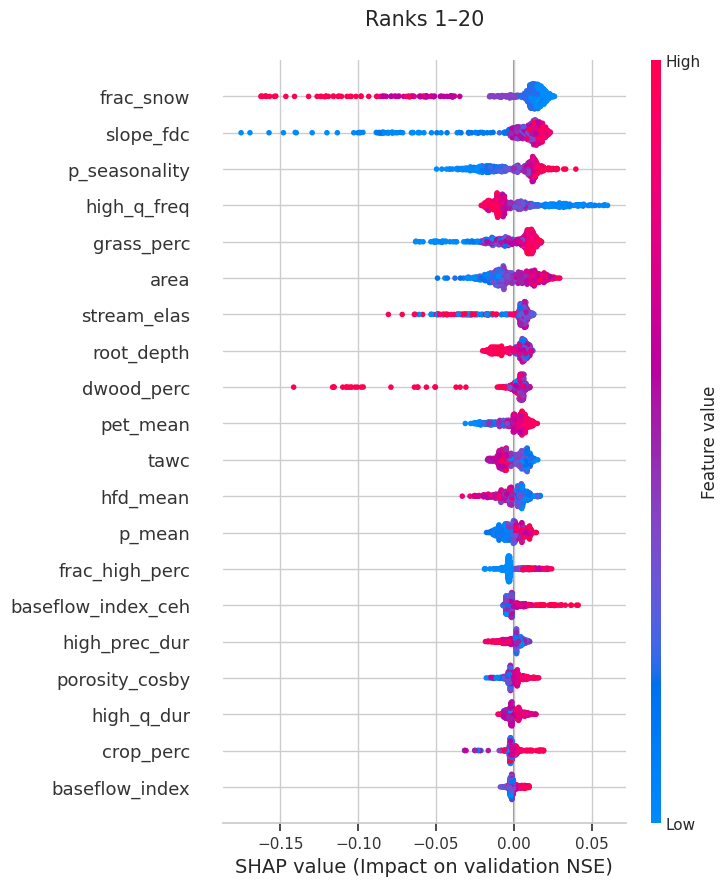

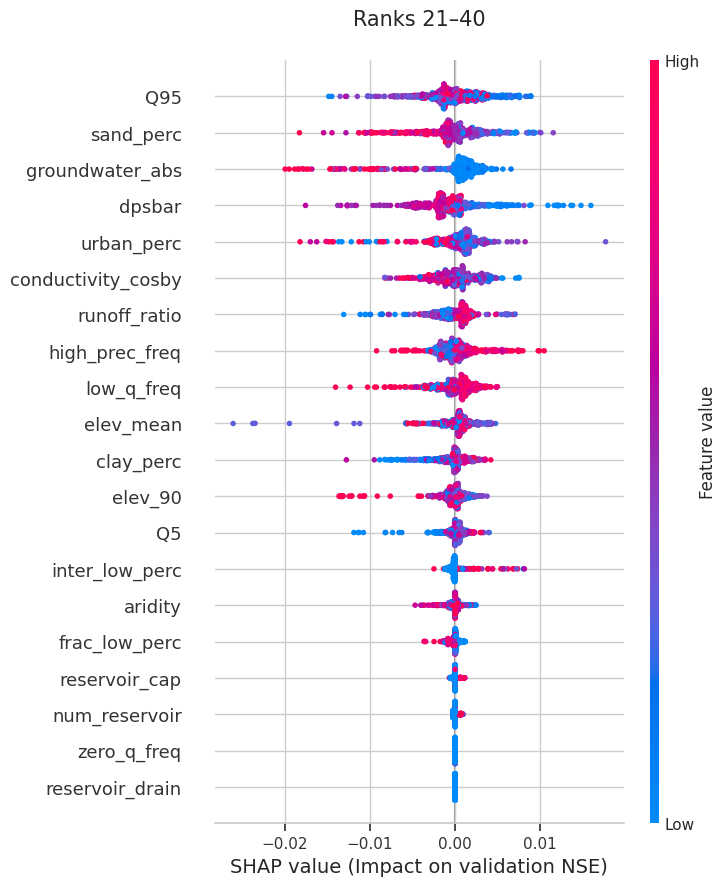

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
from google.colab import files

sns.set(style="whitegrid")

# ============================================================
# 0️⃣ TARGET
# ============================================================

targets = {
    'NSE_val': data['NSE_val']
}

titles = {
    'NSE_val': 'Hydrological Performance (NSE validation)'
}

shap_values_dict = {}
top_features = {}

# ============================================================
# 1️⃣ CLEAN DATA
# ============================================================

X_model = X_clean.copy()

X_model = X_model.select_dtypes(include=['number'])
X_model = X_model.fillna(X_model.median())

# Optional stabilization
X_model = np.log1p(np.abs(X_model))

# ============================================================
# 2️⃣ CROSS VALIDATION + LIGHTGBM
# ============================================================

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, y in targets.items():

    print("\n" + "="*60)
    print(f"Processing target: {name}")
    print("="*60)

    shap_vals_list = []
    X_test_list = []
    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_model), 1):

        print(f"\nFold {fold} / {n_splits}")

        X_train, X_test = X_model.iloc[train_idx], X_model.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_data = lgb.Dataset(X_train, label=y_train)
        test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'learning_rate': 0.03,
            'num_leaves': 31,
            'max_depth': 3,
            'feature_fraction': 0.7,
            'bagging_fraction': 0.7,
            'bagging_freq': 5,
            'min_data_in_leaf': 10,
            'lambda_l2': 2.0,
            'lambda_l1': 0.2,
            'seed': 42,
            'verbosity': -1
        }

        model = lgb.train(
            params,
            train_data,
            num_boost_round=800,
            valid_sets=[test_data],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        print(f"Best iteration: {model.best_iteration}")

        # ====================================================
        # Predictions + Metrics
        # ====================================================

        y_pred = model.predict(X_test, num_iteration=model.best_iteration)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        fold_metrics.append({
            "Fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        print(f"RMSE = {rmse:.4f}")
        print(f"MAE  = {mae:.4f}")
        print(f"R²   = {r2:.4f}")

        # ====================================================
        # SHAP (LightGBM)
        # ====================================================

        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)

        shap_vals_list.append(shap_vals)
        X_test_list.append(X_test)

    # ============================================================
    # CV SUMMARY
    # ============================================================

    metrics_df = pd.DataFrame(fold_metrics)

    print("\n" + "="*60)
    print("Cross-validation Metrics")
    print("="*60)
    print(metrics_df)

    print("\nAverage performance")
    print(f"RMSE : {metrics_df['RMSE'].mean():.4f} ± {metrics_df['RMSE'].std():.4f}")
    print(f"MAE  : {metrics_df['MAE'].mean():.4f} ± {metrics_df['MAE'].std():.4f}")
    print(f"R²   : {metrics_df['R2'].mean():.4f} ± {metrics_df['R2'].std():.4f}")

    # ============================================================
    # 3️⃣ SHAP CONCAT
    # ============================================================

    shap_values_concat = np.vstack(shap_vals_list)
    X_test_concat = pd.concat(X_test_list, axis=0)

    mean_abs_shap = np.abs(shap_values_concat).mean(axis=0)

    feature_importance = pd.Series(
        mean_abs_shap,
        index=X_test_concat.columns
    )

    # 🔥 TOP 20 FEATURES (CHANGED HERE)
    top_features[name] = feature_importance.sort_values(
        ascending=False
    ).head(20)

    shap_values_dict[name] = (shap_values_concat, X_test_concat)

    # ============================================================
    # 4️⃣ SHAP PLOTS (20 FEATURES PER FIGURE)
    # ============================================================

    ranked_features = feature_importance.sort_values(
        ascending=False
    ).index.tolist()

    n_features = len(ranked_features)
    chunk_size = 20

    for start in range(0, n_features, chunk_size):

        end = min(start + chunk_size, n_features)

        feature_subset = ranked_features[start:end]

        X_subset = X_test_concat[feature_subset]

        shap_subset = shap_values_concat[
            :,
            [X_test_concat.columns.get_loc(f) for f in feature_subset]
        ]

        plt.figure(figsize=(12, 0.55 * len(feature_subset) + 2))

        shap.summary_plot(
            shap_subset,
            X_subset,
            feature_names=feature_subset,
            max_display=len(feature_subset),
            sort=False,
            plot_type="dot",
            show=False
        )

        # ========================================================
        # Figure title
        # ========================================================

        if start == 0:
            title = "Ranks 1–20"
        else:
            title = f"Ranks {start+1}–{end}"

        ax = plt.gca()

        ax.set_title(
            title,
            fontsize=15,
            #fontweight="bold",
            pad=25
        )

        ax.set_xlabel(
            "SHAP value (Impact on validation NSE)",
            fontsize=14
        )

        plt.tight_layout(pad=2.5)

        # ========================================================
        # SAVE FIGURE
        # ========================================================

        filename = (
            f"SHAP_LightGBM_{name}_{start+1}_{end}.jpeg"
        )

        plt.savefig(
            filename,
            dpi=700,
            bbox_inches="tight"
        )

        plt.show()

        #files.download(filename)

In [ ]:
keywords = ["arid", "urban", "baseflow", "season", "gw"]

for kw in keywords:
    print(f"\n{kw}:")
    print([c for c in X_model.columns if kw in c.lower()])


arid:
['aridity']

urban:
['urban_perc']

baseflow:
['baseflow_index', 'baseflow_index_ceh']

season:
['p_seasonality']

gw:
[]


In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   